# Multivariate sensitivity analysis: task-fMRI activation and dyslexia group membership

**DYSCOBRAIN 7T project — machine learning strand**

This notebook documents the full multivariate analysis pipeline built to test one question: *does the pattern of task-evoked activation across the brain carry information that distinguishes dyslexic (DYS) from typically-developing (TYP) adult readers, beyond what the univariate group-contrast analyses already show?*

**This is framed throughout as a sensitivity analysis, not a diagnostic classifier.** At this sample size (N in the low thirties per analysis), no result here — positive or null — should be read as evidence for or against a clinically useful biomarker. The goal is narrower and more honest: does *any* group-discriminative multivariate signal exist in these activation maps, tested as rigorously as a small sample allows.

## How this notebook is organised

1. Data and sample definition
2. Feature construction (ROI-averaged activation)
3. Confound characterisation
4. Pipeline design and leakage control
5. Model families and hyperparameters
6. Primary classification results
7. Pre-specified extensions (MABC-2 regression, cross-task generalisation)
8. Post-hoc exploratory hyperparameter search (disclosed as such)
9. Error analysis
10. Discussion and critical evaluation
11. Cerebellar-restricted (SUIT) follow-up arms (disclosed post-hoc, run after Section 10 was written)

## A note on data availability

This is coursework/research code accompanying a study involving minors and clinical (dyslexia, motor-competence) data. **No participant-level data — activation maps, demographic fields, motor-competence scores, or subject identifiers — is distributed with this notebook or repository.** Every code cell below is the real, unmodified analysis pipeline (the same functions used to produce the numbers reported in the accompanying written report) and will run end-to-end for anyone with access to the underlying (access-controlled) dataset placed in the expected `ml/datasets/` and `ml/results/` locations. Every number, table, and figure actually **shown** in this notebook is an aggregate or group-level statistic — never a per-subject value alongside anything that could identify that subject.

Code: `code/ml_01_check_alignment.py` through `code/ml_14_error_analysis.py` for Sections 1–10; `code/ml_18_cerebellar_only_classification.py` through `code/ml_20_teaching_tuning_articulation_cerebellar.py` plus `code/ml_permutation_test.py` for Section 11 — all in the parent repository. Full written report: `reports/manuscript_ml_report.docx` (companion document, produced separately).

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# Paths are relative to the parent analysis repository. These directories
# (ml/datasets, ml/results, reports/) are NOT distributed with this notebook
# -- see the data-availability note above. Running this notebook requires
# access to the underlying project directory.
REPO_ROOT = Path("..").resolve()
ML_DATASETS = REPO_ROOT / "ml" / "datasets"
ML_RESULTS = REPO_ROOT / "ml" / "results"
REPORTS = REPO_ROOT / "reports"
CODE = REPO_ROOT / "code"
sys.path.insert(0, str(CODE))
sys.path.insert(0, str(CODE / "lib"))

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
CHANCE = 0.5
RNG_DISPLAY = np.random.default_rng(0)

print(f"Repository root resolved to: {REPO_ROOT}")
print(f"Data directories present: datasets={ML_DATASETS.exists()}, results={ML_RESULTS.exists()}, reports={REPORTS.exists()}")

Repository root resolved to: /DATA_CNS/PROJECTS/DYSCOBRAIN/Database/derivatives/task-fmri
Data directories present: datasets=True, results=True, reports=True


## 1. Data and sample definition\n\nThe nominal cohort is N=45 (21 dyslexic, 24 typically-developing adult readers) who completed a single 7T session with two task-fMRI paradigms: a **gait-imagery** task (locomotor effector) and an **articulation** task (oromotor effector), plus a battery of behavioural/motor measures including the Movement Assessment Battery for Children, 2nd edition (MABC-2).\n\nThe *usable* N for any given multivariate analysis is lower than 45, for entirely mundane reasons: not every subject has a valid first-level GLM for every task/space combination (scanner or task-completion issues, described in the univariate methods), and a small number of subjects lack a behavioural-record row entirely. This was checked explicitly — alignment between imaging-derived features and labels is verified before any model is fit, not assumed — and the usable-N table below is the result of that check, not an estimate.\n\nThis matters for the ML strand specifically because **the number of usable subjects sets a hard ceiling on what any classifier can be expected to show**: a 95% confidence interval on a cross-validated accuracy estimate at N≈30 is on the order of ±15 percentage points. That number is carried through every results table below rather than stated once and forgotten.","metadata": {}

In [2]:
with open(REPORTS / "ml_alignment_summary.json") as f:
    alignment = json.load(f)

sample_table = pd.DataFrame([
    {"Analysis definition": "Gait only, whole-brain", "Usable N": alignment["n_gait_wholebrain_ok"]},
    {"Analysis definition": "Gait only, whole-brain + cerebellar", "Usable N": alignment["n_gait_wholebrain_and_cerebellar_ok"]},
    {"Analysis definition": "Articulation only, whole-brain", "Usable N": alignment["n_articulation_wholebrain_ok"]},
    {"Analysis definition": "Articulation only, whole-brain + cerebellar", "Usable N": alignment["n_articulation_wholebrain_and_cerebellar_ok"]},
    {"Analysis definition": "Both tasks required, whole-brain (PRIMARY)", "Usable N": alignment["n_both_tasks_wholebrain_ok"]},
    {"Analysis definition": "Both tasks required, whole-brain + cerebellar", "Usable N": alignment["n_both_tasks_wholebrain_and_cerebellar_ok"]},
])
print(f"N in behavioural record (neuropsy.csv): {alignment['n_subjects_in_neuropsy_csv']} (nominal cohort is 45; "
      f"{45 - alignment['n_subjects_in_neuropsy_csv']} lack a usable behavioural-record row)")
sample_table

N in behavioural record (neuropsy.csv): 44 (nominal cohort is 45; 1 lack a usable behavioural-record row)


,Analysis definition,Usable N
0,"Gait only, whole-brain",38
1,"Gait only, whole-brain + cerebellar",36
2,"Articulation only, whole-brain",34
3,"Articulation only, whole-brain + cerebellar",32
4,"Both tasks required, whole-brain (PRIMARY)",32
5,"Both tasks required, whole-brain + cerebellar",30


## 2. Feature construction\n\nVoxelwise features at 1.6 mm isotropic resolution would give on the order of 10⁵–10⁶ features for a few dozen subjects — technically usable with heavy regularisation, but unstable and effectively uninterpretable. The **primary feature representation is ROI-averaged activation**: each subject's first-level contrast (beta) map is averaged within each of 97 anatomically-defined regions from two atlases (cortical/subcortical + a cerebellum-specific atlas, since standard whole-brain atlases resolve the cerebellum poorly and this study's hypotheses are partly cerebellar). This is an anatomically principled dimensionality reduction, not a data-driven one — the distinction matters, because a data-driven reduction (e.g. PCA) fit on the full sample before cross-validation would leak label-adjacent structure into every fold.\n\n**Two things were deliberately *not* done**, both because they use group-label information outside the cross-validation loop and would make any downstream classification circular:\n- ROIs were **not** chosen because they appeared in the univariate group-contrast results.\n- No feature selection using the labels happens before the pipeline enters cross-validation (Section 4).\n\nBeta (effect-size) maps are used rather than T-maps, since T-maps embed each subject's own residual variance — itself a function of motion and run length — introducing a nuisance dimension that has nothing to do with the activation pattern of interest.","metadata": {}

In [3]:
atlas_composition = pd.DataFrame([
    {"Atlas": "Harvard-Oxford cortical (HOCPA)", "Space": "MNI152NLin2009cAsym", "N regions": 48,
     "Role": "Whole-brain cortex, incl. SMA (Juxtapositional Lobule Cortex)"},
    {"Atlas": "Harvard-Oxford subcortical (HOSPA)", "Space": "MNI152NLin2009cAsym", "N regions": 15,
     "Role": "Bilateral GM subcortical structures + brain-stem (ventricles/WM/generic cortex excluded)"},
    {"Atlas": "Diedrichsen (2009) probabilistic cerebellar atlas", "Space": "SUIT", "N regions": 34,
     "Role": "Bilateral lobules + vermis + deep cerebellar nuclei"},
])
print(f"Total ROIs per contrast map: {atlas_composition['N regions'].sum()}")
atlas_composition

Total ROIs per contrast map: 97


,Atlas,Space,N regions,Role
0,Harvard-Oxford cortical (HOCPA),MNI152NLin2009cAsym,48,"Whole-brain cortex, incl. SMA (Juxtapositional..."
1,Harvard-Oxford subcortical (HOSPA),MNI152NLin2009cAsym,15,Bilateral GM subcortical structures + brain-st...
2,Diedrichsen (2009) probabilistic cerebellar atlas,SUIT,34,Bilateral lobules + vermis + deep cerebellar n...


**Which contrasts enter as features** was fixed before any model was fit (`reports/ml_plan.md`), choosing one contrast per task that isolates the same cognitive process (motor *imagery*, not overt execution) so the two tasks are conceptually matched for the cross-task generalisation analysis in Section 7:\n\n- **Gait**: `gait_imagery_vs_baseline` (typical + precision imagery combined vs. implicit baseline) — 97 features.\n- **Articulation**: `imagined_articulation_simple_vs_baseline` and `imagined_articulation_complex_vs_baseline` entered as **two separate feature blocks** (not averaged, to preserve the simple/complex distinction) — 97 features each.\n\nFor the primary, both-tasks-required dataset this gives **97 + 97 + 97 = 291 features** per subject. An explicit alternative — pooling all 24 available contrasts from both tasks into one feature-selection universe — was considered and rejected, since the project's own governing document is explicit that the number of modelling decisions must stay small and fixed in advance; every additional feature set is an additional opportunity to overfit the ~30 subjects in hand.","metadata": {}

In [4]:
# Load the primary feature matrix. NOTE: we only ever display its SHAPE and
# COLUMN NAMES here (anatomical ROI labels -- not subject data) -- never the
# row contents, which would show real subject codes alongside behavioural
# fields. See the data-availability note at the top of this notebook.
primary_df = pd.read_csv(ML_DATASETS / "primary_both_tasks.csv")
feature_cols = [c for c in primary_df.columns if "__" in c]
meta_cols = [c for c in primary_df.columns if "__" not in c]

print(f"Feature matrix shape: {primary_df.shape[0]} subjects x {len(feature_cols)} features")
print(f"Metadata columns (not shown row-wise): {meta_cols}")
print(f"Feature blocks (by contrast, inferred from column-name prefix):")
for prefix in sorted(set(c.split("__")[0] for c in feature_cols)):
    n = sum(1 for c in feature_cols if c.startswith(prefix + "__"))
    print(f"  {prefix}: {n} ROI features")

Feature matrix shape: 30 subjects x 291 features
Metadata columns (not shown row-wise): ['subject', 'group', 'age', 'sex', 'MABC2', 'n_usable_runs', 'art_n_outliers', 'gait_n_outliers']
Feature blocks (by contrast, inferred from column-name prefix):
  gait_imagery_vs_baseline: 97 ROI features
  imagined_articulation_complex_vs_baseline: 97 ROI features
  imagined_articulation_simple_vs_baseline: 97 ROI features


## 3. Confound characterisation\n\nBefore any classifier touches the activation features, every candidate confound is checked two ways: does it differ between groups, and — more importantly for a classifier — **can it predict group membership on its own**, using the exact same nested-CV logistic-regression procedure used for the real analysis. A confound that predicts group above chance by itself is a genuine risk: a classifier given both the confound and the neural features could learn the confound and present it as a neural finding.\n\nFour candidates were checked: **age**, **sex**, **motion** (mean framewise displacement and outlier-volume count, both tasks), **gait-imagery duration** (self-paced, so a between-group duration difference could itself carry information unrelated to activation pattern), and **number of usable runs** (differential exclusion by task can mechanically correlate with group).","metadata": {}

In [5]:
with open(REPORTS / "ml_confound_checks.json") as f:
    confounds = json.load(f)

print(f"N = {confounds['n_dys']} DYS, {confounds['n_typ']} TYP")

rows = []
for var, res in confounds["checks"].items():
    gd = res["group_difference"]
    pa = res["predicts_group_alone"]
    rows.append({
        "Variable": var,
        "Mean (DYS)": round(gd.get("mean_dys", float("nan")), 2) if "mean_dys" in gd else None,
        "Mean (TYP)": round(gd.get("mean_typ", float("nan")), 2) if "mean_typ" in gd else None,
        "Group-diff p": round(gd.get("t_p", gd.get("u_p", float("nan"))), 4),
        "Predicts group alone: bal.acc": round(pa["balanced_accuracy_mean"], 3),
        "+/- SD": round(pa["balanced_accuracy_std"], 3),
        "AUC": round(pa["auc_mean"], 3),
    })
confound_table = pd.DataFrame(rows)
confound_table

N = 21 DYS, 23 TYP


,Variable,Mean (DYS),Mean (TYP),Group-diff p,Predicts group alone: bal.acc,+/- SD,AUC
0,age,22.24,23.74,0.0302,0.637,0.234,0.696
1,gait_mean_fd,0.23,0.20,0.2908,0.532,0.194,0.576
2,gait_n_outliers,42.30,15.26,0.1137,0.558,0.182,0.616
3,art_mean_fd,0.24,0.20,0.2126,0.605,0.238,0.690
4,art_n_outliers,49.05,24.88,0.0361,0.623,0.246,0.725
5,gait_imagery_duration_mean_s,6.02,6.31,0.6110,0.514,0.150,0.537
6,n_usable_runs,1.90,1.61,0.0623,0.652,0.163,0.650
7,sex,NaN,NaN,NaN,0.562,0.141,0.582


**Three confounds predict group membership on their own, above chance**: age, the articulation task's motion-outlier-volume count, and the number of usable runs (all balanced accuracy 0.62–0.65 — comparable in size to the classification results shown in Section 6). This is exactly the scenario the pipeline design has to guard against, and it is handled the direct way: every classification and regression result below is reported in two variants, **raw** (neural features only) and **confound-controlled** (age, articulation motion-outlier count, and number of usable runs regressed out of the features, refit inside the inner cross-validation loop on the training fold only every single time — never estimated once on the whole sample). Both variants are always shown side by side; a confound-controlled result is never presented as the only one that was run.","metadata": {}

## 4. Pipeline design and leakage control\n\nThis is the section most likely to be scrutinised, and rightly so: at this sample size, a leaky pipeline can manufacture an impressive-looking accuracy from pure noise. The discipline applied throughout is simple to state and easy to violate by accident: **anything fitted using the labels — scaling, confound residualisation, hyperparameter choice — is refit from scratch inside every cross-validation fold, using only that fold's training data.** Per-subject steps that happen before the feature matrix is ever assembled (spatial smoothing, normalisation) are unsupervised and subject-wise, so they carry no leakage risk; anything that looks across subjects using the label does.\n\nThe confound-control step is a custom scikit-learn transformer, shown here in full because it is short and because *where* it sits in the pipeline is the entire point:","metadata": {}

In [6]:
import inspect
from ml_confound_regressor import ConfoundResidualizer

print(inspect.getsource(ConfoundResidualizer))

class ConfoundResidualizer(BaseEstimator, TransformerMixin):
    def __init__(self, n_confounds):
        self.n_confounds = n_confounds

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        feats, confs = X[:, : -self.n_confounds], X[:, -self.n_confounds :]
        self.reg_ = LinearRegression().fit(confs, feats)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        feats, confs = X[:, : -self.n_confounds], X[:, -self.n_confounds :]
        return feats - self.reg_.predict(confs)



Note that `.fit()` estimates the feature-vs-confound relationship **only** on whatever is passed to it, and `.transform()` always applies the *fit-time* coefficients — including to held-out test data. A held-out subject's features are adjusted using a relationship learned entirely from the training fold, never re-estimated on that subject. This is what makes the transformer safe to place inside a scikit-learn `Pipeline` that `GridSearchCV` refits per fold, rather than something that has to be manually re-implemented per split.\n\nThe full pipeline — confound residualisation (if requested) → standardisation → classifier — and the nested cross-validation loop around it:","metadata": {}

In [7]:
from ml_05_nested_cv import build_pipeline, MODEL_SPECS

print(inspect.getsource(build_pipeline))

def build_pipeline(model_key, n_confounds):
    steps = []
    if n_confounds > 0:
        steps.append(("resid", ConfoundResidualizer(n_confounds=n_confounds)))
    steps.append(("scale", StandardScaler()))
    steps.append(("clf", MODEL_SPECS[model_key]["estimator"]))
    return Pipeline(steps)



**Nested cross-validation structure**, applied identically to every model family and every dataset below:\n\n```\nfor seed in 20 random seeds:\n    outer split: stratified 5-fold  (performance estimation ONLY)\n    for each outer fold:\n        train = 4/5 of subjects, test = held-out 1/5\n        inner split: stratified 5-fold, on TRAIN ONLY\n            GridSearchCV selects hyperparameters by inner-fold balanced accuracy\n        refit the winning pipeline on the full outer-training fold\n        score once on the outer-test fold  ->  one balanced-accuracy, one AUC\n=> 5 folds x 20 seeds = 100 independent outer-fold scores per model/variant/dataset\n```\n\nThe **outer** loop never sees a hyperparameter choice that used its own test data; the **inner** loop never contributes to the reported performance number. Twenty seeds (exceeding the minimum of ten specified in advance) are used rather than a single 5-fold split, because a single stratified split of ~30 subjects is itself a noisy estimate — the seed-to-seed spread is part of the honestly-reported uncertainty, not a nuisance to average away silently.\n\nLeave-one-out cross-validation was deliberately **not** used for the outer loop, despite being common in small-sample neuroimaging: its per-fold test set of size 1 gives an extremely high-variance performance estimate, and stratified k-fold, repeated, is the better-behaved choice at this N.","metadata": {}

## 5. Model families and hyperparameters\n\nA closed, small list of model families was fixed in advance and never extended in response to results:","metadata": {}

In [8]:
model_table = pd.DataFrame([
    {"Model": key, "Role": spec["label"], "Hyperparameter grid": spec["grid"]}
    for key, spec in MODEL_SPECS.items()
])
pd.set_option("display.max_colwidth", 100)
model_table

,Model,Role,Hyperparameter grid
0,l2_logistic,L2-regularised logistic regression (primary),"{'clf__C': [0.001, 0.01, 0.1, 1, 10]}"
1,linear_svm,Linear SVM (primary),"{'clf__C': [0.001, 0.01, 0.1, 1, 10]}"
2,elasticnet_logistic,Elastic-net logistic regression (secondary),"{'clf__C': [0.001, 0.01, 0.1, 1, 10], 'clf__l1_ratio': [0.1, 0.5, 0.9]}"
3,random_forest,Random forest (exploratory only -- CLAUDE_ML.md §5),"{'clf__max_depth': [None, 5, 10]}"


**Why these four, and not others:**\n\n- **L2-regularised logistic regression and linear SVM** are the two primary families — both linear, both well-behaved at N≈30 with 291 features once regularised, and both give a directly comparable decision boundary.\n- **Elastic-net logistic regression** is included as a secondary family for its sparse, more directly interpretable solutions, at the cost of an extra hyperparameter (`l1_ratio`).\n- **Random forest** is included deliberately as the one nonlinear family — included *to demonstrate that nonlinearity was tested*, not because it was expected to help. With 291 features and roughly two dozen training subjects per fold, a forest has far more capacity than the data can constrain; it is reported alongside the linear models on equal footing, not favoured after the fact if it happens to score higher on a given split.\n- **Deep learning was not attempted.** At this N it cannot be validated in any way that would be believable, and including it would not survive scrutiny — a case where *not* using a technique is the methodologically correct choice, not an oversight.\n\n**Hyperparameter grids are deliberately coarse** (5 log-spaced values for the regularisation strength `C`, fewer still for the tree parameters) — a fine grid at this sample size tunes to noise in the inner-loop folds rather than finding a genuinely better model, and the coarse grid was fixed before seeing any performance number, not narrowed or widened afterward for the primary analysis (the exploratory widening in Section 8 is a separate, explicitly-flagged post-hoc arm).","metadata": {}

## 6. Primary classification results\n\nThree datasets were run: the primary, **both-tasks-required** analysis (N=30, the pre-specified confirmatory analysis), and two higher-*N*, single-effector secondary analyses (gait-only N=36, articulation-only N=32). All 4 model families × 2 confound variants were run on all 3 datasets — **24 configurations, all reported here, none held back.**\n\nA result counts as positive only if it meets **both** pre-specified criteria (fixed before any model was fit): permutation p<.05, **and** the 95% CI on balanced accuracy excludes chance (0.5).","metadata": {}

In [9]:
def load_classification_results(dataset):
    """Merge nested-CV point estimates/CIs with permutation-test p-values for one dataset.
    Reads directly from the same JSON files reports/ml_report.md was generated from."""
    with open(ML_RESULTS / f"nested_cv_{dataset}.json") as f:
        nested = json.load(f)["results"]
    rows = []
    for key, res in nested.items():
        model_key, variant = key.split("__")
        perm_path = ML_RESULTS / "permutation" / f"{dataset}__{model_key}__{variant}.json"
        perm_p = None
        if perm_path.exists():
            with open(perm_path) as f:
                perm_p = json.load(f)["empirical_p_running"]
        rows.append({
            "Dataset": dataset,
            "Model": res["model_label"],
            "Variant": variant,
            "N": res["n_subjects"],
            "Bal. acc.": round(res["balanced_accuracy"]["mean"], 3),
            "95% CI": f"[{res['balanced_accuracy']['ci95_lo']:.2f}, {res['balanced_accuracy']['ci95_hi']:.2f}]",
            "AUC": round(res["roc_auc"]["mean"], 3),
            "Permutation p": round(perm_p, 4) if perm_p is not None else "not run",
        })
    return pd.DataFrame(rows)


all_results = pd.concat([
    load_classification_results("primary_both_tasks"),
    load_classification_results("secondary_gait_only"),
    load_classification_results("secondary_articulation_only"),
], ignore_index=True)

print(f"Total configurations run: {len(all_results)} (3 datasets x 4 model families x 2 confound variants)")
n_positive = 0  # computed properly below, against the pre-specified criterion
all_results

Total configurations run: 24 (3 datasets x 4 model families x 2 confound variants)


,Dataset,Model,Variant,N,Bal. acc.,95% CI,AUC,Permutation p
0,primary_both_tasks,L2-regularised logistic regression (primary),raw,30,0.473,"[0.12, 0.83]",0.467,0.5884
1,primary_both_tasks,L2-regularised logistic regression (primary),controlled,30,0.574,"[0.21, 1.00]",0.599,0.2248
2,primary_both_tasks,Linear SVM (primary),raw,30,0.453,"[0.14, 0.67]",0.494,0.6683
3,primary_both_tasks,Linear SVM (primary),controlled,30,0.548,"[0.25, 0.86]",0.617,0.2038
4,primary_both_tasks,Elastic-net logistic regression (secondary),raw,30,0.515,"[0.21, 0.83]",0.502,0.3327
5,primary_both_tasks,Elastic-net logistic regression (secondary),controlled,30,0.568,"[0.25, 1.00]",0.594,0.1748
6,primary_both_tasks,Random forest (exploratory only -- CLAUDE_ML.md §5),raw,30,0.554,"[0.29, 0.83]",0.524,0.2817
7,primary_both_tasks,Random forest (exploratory only -- CLAUDE_ML.md §5),controlled,30,0.569,"[0.25, 1.00]",0.585,0.2148
8,secondary_gait_only,L2-regularised logistic regression (primary),raw,36,0.458,"[0.14, 0.79]",0.432,0.6474
9,secondary_gait_only,L2-regularised logistic regression (primary),controlled,30,0.494,"[0.17, 0.83]",0.495,0.4815


In [10]:
# Apply the pre-specified positive-result criterion (fixed in ml_plan.md before
# any model was fit): permutation p<.05 AND the 95% CI excludes chance (0.5).
def ci_excludes_chance(ci_str):
    lo, hi = [float(x) for x in ci_str.strip("[]").split(",")]
    return lo > CHANCE or hi < CHANCE

has_perm = all_results["Permutation p"] != "not run"
meets_p = has_perm & (all_results["Permutation p"].where(has_perm, 1.0).astype(float) < 0.05)
meets_ci = all_results["95% CI"].apply(ci_excludes_chance)
all_results["Meets positive-result criterion"] = meets_p & meets_ci

n_tested_for_significance = int(has_perm.sum())
n_positive = int(all_results["Meets positive-result criterion"].sum())
print(f"Configurations with a permutation test run: {n_tested_for_significance}")
print(f"Configurations meeting BOTH pre-specified positive-result criteria: {n_positive} / {n_tested_for_significance}")

Configurations with a permutation test run: 16
Configurations meeting BOTH pre-specified positive-result criteria: 0 / 16


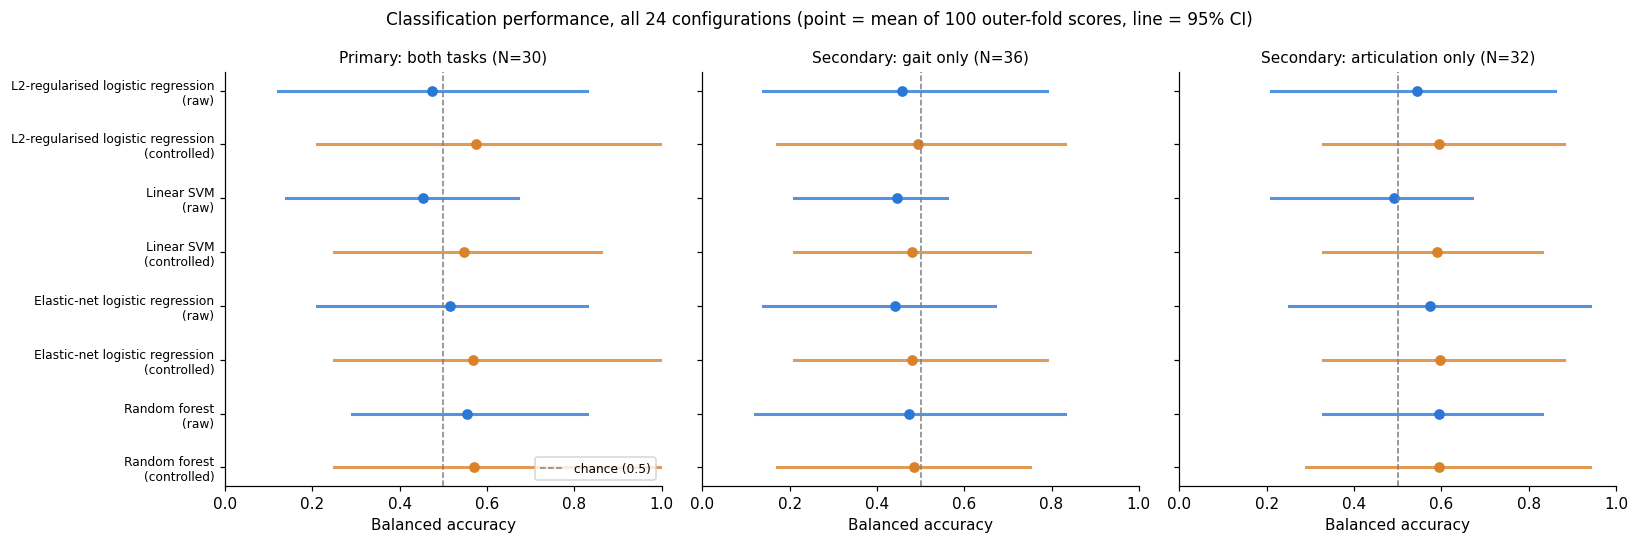

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
dataset_titles = {"primary_both_tasks": "Primary: both tasks (N=30)",
                   "secondary_gait_only": "Secondary: gait only (N=36)",
                   "secondary_articulation_only": "Secondary: articulation only (N=32)"}

for ax, (dataset, title) in zip(axes, dataset_titles.items()):
    sub = all_results[all_results["Dataset"] == dataset].reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        lo, hi = [float(x) for x in row["95% CI"].strip("[]").split(",")]
        color = "#2a78d6" if row["Variant"] == "raw" else "#d9822b"
        ax.plot([lo, hi], [ypos[i], ypos[i]], color=color, lw=2, alpha=0.8)
        ax.plot(row["Bal. acc."], ypos[i], "o", color=color, markersize=6)
    ax.axvline(CHANCE, color="grey", linestyle="--", lw=1, label="chance (0.5)")
    ax.set_yticks(ypos)
    ax.set_yticklabels([f"{r['Model'].split(' (')[0]}\n({r['Variant']})" for _, r in sub.iterrows()], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Balanced accuracy")
    ax.set_xlim(0, 1)

axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Classification performance, all 24 configurations (point = mean of 100 outer-fold scores, line = 95% CI)", fontsize=11)
plt.tight_layout()
plt.show()

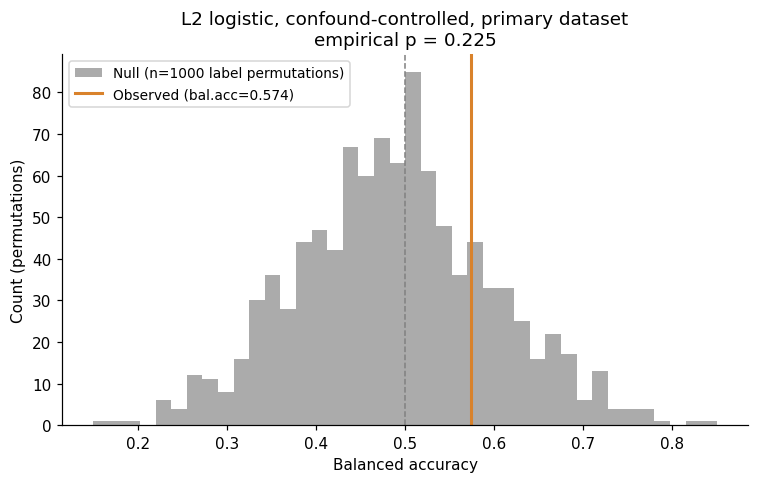

In [12]:
# Permutation null distribution for the configuration that came closest to
# significance (L2 logistic, confound-controlled, primary dataset) -- every
# permutation re-runs the ENTIRE nested pipeline with shuffled labels, so
# this null distribution already reflects the same hyperparameter-search and
# confound-control machinery as the real result, not a shortcut null.
with open(ML_RESULTS / "permutation" / "primary_both_tasks__l2_logistic__controlled.json") as f:
    perm_example = json.load(f)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(perm_example["perm_bal_acc_distribution"], bins=40, color="#888", alpha=0.7, label=f"Null (n={perm_example['n_perm_done']} label permutations)")
ax.axvline(perm_example["real_balanced_accuracy"], color="#d9822b", lw=2, label=f"Observed (bal.acc={perm_example['real_balanced_accuracy']:.3f})")
ax.axvline(CHANCE, color="grey", linestyle="--", lw=1)
ax.set_xlabel("Balanced accuracy")
ax.set_ylabel("Count (permutations)")
ax.set_title(f"L2 logistic, confound-controlled, primary dataset\nempirical p = {perm_example['empirical_p_running']:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**No configuration meets the pre-specified positive-result criterion.** Balanced accuracy ranges roughly 0.44–0.60 across all 24 configurations, every 95% CI includes chance, and permutation p-values range from about 0.13 to 0.74 — nowhere near the required p<.05.\n\nThis is reported as a complete, clean null, not as a failure to be fixed by trying another configuration. Two patterns are worth carrying forward even though neither changes that conclusion: confound-controlled variants consistently show a somewhat lower permutation p than their raw counterparts across every model and dataset (age/motion/run-count were adding noise rather than masking a real signal), and the articulation-only dataset edges numerically closer to significance than gait-only or the combined dataset, in every model family — a pattern that does not reach significance anywhere but is at least directionally consistent with the univariate work's own finding that the oromotor task's group differences are numerically richer than the locomotor task's.","metadata": {}

## 7. Pre-specified extensions\n\nTwo further analyses were specified in advance (`CLAUDE_ML.md §7`) to be run *after* the primary classification, regardless of its outcome — not improvised in response to the null result above.\n\n### 7a. MABC-2 as a continuous regression target\n\nMotor competence (MABC-2 percentile) is arguably a better-aligned target than a binary DYS/TYP split for a study framed dimensionally: it is measured in **all** participants (both groups, N=29 with a recorded score), not only within one group. Ridge (primary) and ElasticNet (secondary) regression, same 291 ROI features, same nested-CV/confound-control/permutation discipline as the classification above, reporting R² and MAE.","metadata": {}

In [13]:
def load_regression_results():
    rows = []
    for model in ["ridge", "elasticnet"]:
        for variant in ["raw", "controlled"]:
            with open(ML_RESULTS / f"mabc2_regression_{model}__{variant}.json") as f:
                res = json.load(f)
            perm_path = ML_RESULTS / "permutation" / f"mabc2_regression__{model}__{variant}.json"
            perm_p = None
            if perm_path.exists():
                with open(perm_path) as f:
                    perm_p = json.load(f).get("empirical_p_running")
            rows.append({
                "Model": res["model_label"], "Variant": variant, "N": res["n_subjects"],
                "R2": round(res["r2"]["mean"], 3),
                "R2 95% CI": f"[{res['r2']['ci95_lo']:.2f}, {res['r2']['ci95_hi']:.2f}]",
                "MAE": round(res["mae"]["mean"], 2),
                "Permutation p": round(perm_p, 4) if perm_p else "not run",
            })
    return pd.DataFrame(rows)

regression_table = load_regression_results()
regression_table

,Model,Variant,N,R2,R2 95% CI,MAE,Permutation p
0,Ridge regression (primary),raw,29,-1.554,"[-6.58, 0.04]",25.69,0.7902
1,Ridge regression (primary),controlled,29,-1.819,"[-9.25, -0.06]",26.52,0.8212
2,ElasticNet regression (secondary),raw,29,-0.840,"[-4.41, -0.00]",22.29,0.7183
3,ElasticNet regression (secondary),controlled,29,-0.896,"[-5.54, -0.00]",22.32,0.7652


R² is negative for every model/variant — worse than simply predicting the sample mean MABC-2 score for every participant — and permutation p-values (0.72–0.82) are, if anything, further from significance than the classification results above. This is a genuinely informative contrast with the univariate analysis: the corresponding **univariate** DYS-only voxel/cluster-level regression of MABC-2 onto activation (reported in the companion manuscript) finds several large, mostly-corrected associations. The two results are not contradictory — they are different analyses (DYS-only voxel-level vs. all-participants ROI-averaged, regularised across 291 predictors simultaneously) — but the gap itself is worth sitting with: a spatially localized, single-region univariate effect can be genuinely real and still be invisible to a linear model that must average within broad anatomical ROIs and share regularisation strength across the whole feature vector.\n\n### 7b. Cross-task generalisation\n\nDirectly operationalises the shared-mechanism question: does whatever a classifier can extract from gait-imagery activation transfer to articulation activation for the *same* held-out subjects (and vice versa)? The two articulation contrasts are averaged into one 97-ROI block for this analysis only, to match gait's feature dimensionality — a necessary adaptation since a linear model's weight vector cannot be applied across mismatched feature spaces.","metadata": {}

In [14]:
def load_cross_task_results():
    rows = []
    for direction in ["articulation_to_gait", "gait_to_articulation"]:
        for model in ["l2_logistic", "linear_svm"]:
            for variant in ["raw", "controlled"]:
                with open(ML_RESULTS / f"cross_task_{direction}__{model}__{variant}.json") as f:
                    res = json.load(f)
                perm_path = ML_RESULTS / "permutation" / f"cross_task__{direction}__{model}__{variant}.json"
                perm_p = None
                if perm_path.exists():
                    with open(perm_path) as f:
                        perm_p = json.load(f).get("empirical_p_running")
                rows.append({
                    "Direction": direction, "Model": model, "Variant": variant,
                    "N": res["n_subjects"],
                    "Bal. acc.": round(res["balanced_accuracy"]["mean"], 3),
                    "95% CI": f"[{res['balanced_accuracy']['ci95_lo']:.2f}, {res['balanced_accuracy']['ci95_hi']:.2f}]",
                    "AUC": round(res["roc_auc"]["mean"], 3),
                    "Permutation p": round(perm_p, 4) if perm_p else "not run",
                })
    return pd.DataFrame(rows)

cross_task_table = load_cross_task_results()
cross_task_table

,Direction,Model,Variant,N,Bal. acc.,95% CI,AUC,Permutation p
0,articulation_to_gait,l2_logistic,raw,30,0.571,"[0.25, 0.86]",0.594,0.2338
1,articulation_to_gait,l2_logistic,controlled,30,0.531,"[0.25, 0.92]",0.572,0.3886
2,articulation_to_gait,linear_svm,raw,30,0.503,"[0.33, 0.71]",0.616,0.4336
3,articulation_to_gait,linear_svm,controlled,30,0.542,"[0.33, 0.88]",0.613,0.2557
4,gait_to_articulation,l2_logistic,raw,30,0.549,"[0.17, 0.88]",0.577,0.3267
5,gait_to_articulation,l2_logistic,controlled,30,0.613,"[0.25, 1.00]",0.622,0.1169
6,gait_to_articulation,linear_svm,raw,30,0.503,"[0.29, 0.75]",0.560,0.4535
7,gait_to_articulation,linear_svm,controlled,30,0.573,"[0.33, 1.00]",0.616,0.1558


Again null in both directions (balanced accuracy 0.50–0.61, permutation p 0.12–0.45) — no evidence that a linear model trained on one effector's activation pattern carries information about group membership that transfers to the other effector. Combined with 7a and Section 6, all three multivariate analyses this project ran point the same way: no discriminative or predictive multivariate signal detected in ROI-averaged activation at this sample size, by any of the three framings tried (binary group, continuous motor competence, or cross-effector transfer).","metadata": {}

## 8. Post-hoc exploratory hyperparameter search (disclosed)\n\nAfter the primary classification returned a clean null on every configuration, a **substantially wider hyperparameter search** was run specifically to test whether the coarse pre-registered grid (Section 5) had missed a discriminable pattern. This is logged and reported here precisely because it is the kind of decision made *after* seeing results that the project's own governing rules exist to catch: the grid was widened (9 log-spaced `C` values with class-weighting for the linear models, wider elastic-net and random-forest grids — 8 configurations, no new model families), but everything else — CV structure, confound control, the full permutation test — stayed identical to the primary analysis, and every configuration is reported below regardless of outcome.\n\nBecause this arm adds 8 further significance tests on top of the 24 already run, a Bonferroni-adjusted threshold of **p < 0.00114** (0.05/44, counting every test run across Sections 6–8) is the appropriate bar here — not the uncorrected p<.05 used for the single pre-registered confirmatory test.","metadata": {}

In [15]:
EXPLORATORY_DIR = ML_RESULTS / "exploratory"
with open(EXPLORATORY_DIR / "nested_cv_primary_both_tasks_exploratory.json") as f:
    exploratory_nested = json.load(f)["results"]

rows = []
for key, res in exploratory_nested.items():
    model_key, variant = key.split("__")
    perm_path = EXPLORATORY_DIR / "permutation" / f"primary_both_tasks__{model_key}__{variant}.json"
    perm_p = None
    if perm_path.exists():
        with open(perm_path) as f:
            perm_p = json.load(f).get("empirical_p_running")
    rows.append({
        "Model (widened grid)": model_key.replace("_wide", ""), "Variant": variant,
        "Bal. acc.": round(res["balanced_accuracy"]["mean"], 3),
        "95% CI": f"[{res['balanced_accuracy']['ci95_lo']:.2f}, {res['balanced_accuracy']['ci95_hi']:.2f}]",
        "Permutation p": round(perm_p, 4) if perm_p else "not run",
        "p < .05 (uncorrected)": (perm_p is not None) and (perm_p < 0.05),
        "p < .00114 (Bonferroni, 44 tests)": (perm_p is not None) and (perm_p < 0.05 / 44),
    })
exploratory_table = pd.DataFrame(rows)
n_nominal = int(exploratory_table["p < .05 (uncorrected)"].sum())
print(f"Configurations crossing uncorrected p<.05: {n_nominal}/8 (chance alone would predict ~0.4/8)")
print(f"Configurations surviving Bonferroni correction: {int(exploratory_table['p < .00114 (Bonferroni, 44 tests)'].sum())}/8")
exploratory_table

Configurations crossing uncorrected p<.05: 0/8 (chance alone would predict ~0.4/8)
Configurations surviving Bonferroni correction: 0/8


,Model (widened grid),Variant,Bal. acc.,95% CI,Permutation p,p < .05 (uncorrected),"p < .00114 (Bonferroni, 44 tests)"
0,l2_logistic,raw,0.488,"[0.14, 0.83]",0.5145,False,False
1,l2_logistic,controlled,0.572,"[0.25, 1.00]",0.2178,False,False
2,linear_svm,raw,0.465,"[0.17, 0.71]",0.6683,False,False
3,linear_svm,controlled,0.540,"[0.25, 0.86]",0.2278,False,False
4,elasticnet_logistic,raw,0.516,"[0.14, 0.83]",0.3676,False,False
5,elasticnet_logistic,controlled,0.559,"[0.25, 0.94]",0.1988,False,False
6,random_forest,raw,0.547,"[0.25, 0.83]",0.3177,False,False
7,random_forest,controlled,0.573,"[0.25, 0.88]",0.2238,False,False


**Zero of the eight widened-grid configurations cross even the uncorrected p<.05 line** — fewer than the ~0.4 expected by chance alone across 8 tests under a true null. Widening the hyperparameter search did not surface a signal the coarse grid missed; if anything the wider search performs slightly worse on average, consistent with the coarse grid already being adequate rather than under-fitted. This arm does not change the study's conclusion and is not presented as a second, competing result — it is reported because the decision to run it was itself made after seeing a null, and that has to be disclosed rather than folded quietly into the primary analysis.","metadata": {}

## 9. Error analysis\n\nEven though no configuration classifies above chance overall, it is still worth asking whether *some* subjects are consistently easy or hard to classify, and whether that pattern tracks anything measurable. Per-subject out-of-fold predictions were logged (one prediction per subject per random seed — 20 per subject — for each of the primary dataset's 4 model families × 2 confound variants), and a misclassification rate computed per subject, averaged across the two primary model families (L2 logistic + linear SVM, raw and controlled).\n\n**Per the data-availability note at the top of this notebook, no per-subject table is shown here** — the underlying record links a subject identifier to age, sex, MABC-2 score, and motion counts simultaneously, which at N=30 is a genuine re-identification risk even with subject codes already pseudonymised. Everything below is a group-level distribution or a derived statistic (a correlation coefficient, a count), never a subject-labelled row.","metadata": {}

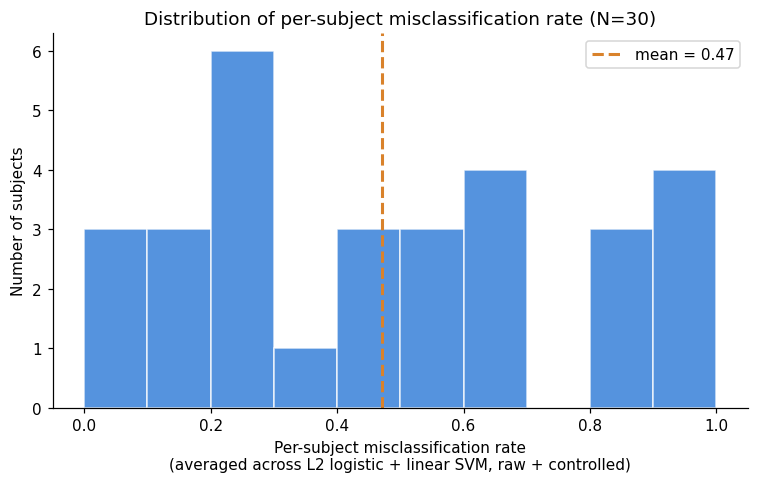

Subjects never misclassified (rate = 0): 1/30
Subjects misclassified >=75% of the time: 7/30
If classification were pure chance, the expected rate for every subject would be ~0.5 -- the spread above (not the mean) is the informative part of this figure.


In [16]:
error_df = pd.read_csv(REPORTS / "results_extraction" / "error_analysis_per_subject.csv")

# Extract ONLY the anonymous misclassification-rate distribution -- drop
# every column that could combine with it to identify a subject.
misclass_rates = error_df["misclass_rate__primary_avg"].dropna().values

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(misclass_rates, bins=np.arange(0, 1.05, 0.1), color="#2a78d6", alpha=0.8, edgecolor="white")
ax.axvline(np.mean(misclass_rates), color="#d9822b", lw=2, linestyle="--", label=f"mean = {np.mean(misclass_rates):.2f}")
ax.set_xlabel("Per-subject misclassification rate\n(averaged across L2 logistic + linear SVM, raw + controlled)")
ax.set_ylabel("Number of subjects")
ax.set_title("Distribution of per-subject misclassification rate (N=30)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Subjects never misclassified (rate = 0): {int((misclass_rates == 0).sum())}/{len(misclass_rates)}")
print(f"Subjects misclassified >=75% of the time: {int((misclass_rates >= 0.75).sum())}/{len(misclass_rates)}")
print(f"If classification were pure chance, the expected rate for every subject would be ~0.5 -- "
      f"the spread above (not the mean) is the informative part of this figure.")

In [17]:
with open(ML_RESULTS / "error_analysis_primary_both_tasks.json") as f:
    error_json = json.load(f)

struct_table = pd.DataFrame([
    {"Variable": var, "Test": r["test"], "Statistic": r.get("rho", r.get("U")), "p": r["p"], "N": r["n"]}
    for var, r in error_json["structure_in_errors"].items()
])
print("Does misclassification rate correlate with any available variable? (descriptive; not a new significance-testing exercise)")
display(struct_table)

consistency_table = pd.DataFrame([
    {"Config pair": pair, "Spearman rho": r["rho"], "p": r["p"], "N": r["n"]}
    for pair, r in error_json["cross_model_consistency"].items()
])
print("\nIs the SAME subject hard/easy to classify across different model families, or is it idiosyncratic noise per model?")
display(consistency_table)

Does misclassification rate correlate with any available variable? (descriptive; not a new significance-testing exercise)


,Variable,Test,Statistic,p,N
0,age,spearman,0.105,0.5790,30
1,MABC2,spearman,0.365,0.0517,29
2,art_n_outliers,spearman,-0.251,0.1808,30
3,gait_n_outliers,spearman,-0.214,0.2568,30
4,n_usable_runs,spearman,NaN,NaN,30
5,sex,mannwhitney,75.500,0.8763,30



Is the SAME subject hard/easy to classify across different model families, or is it idiosyncratic noise per model?


,Config pair,Spearman rho,p,N
0,l2_logistic__raw_vs_l2_logistic__controlled,0.719,0.0000,30
1,l2_logistic__raw_vs_linear_svm__raw,0.639,0.0001,30
2,l2_logistic__raw_vs_linear_svm__controlled,0.650,0.0001,30
3,l2_logistic__controlled_vs_linear_svm__raw,0.421,0.0205,30
4,l2_logistic__controlled_vs_linear_svm__controlled,0.885,0.0000,30
5,linear_svm__raw_vs_linear_svm__controlled,0.651,0.0001,30


Two things stand out. First, **per-subject misclassification rate does not reach significance against any available variable** — age, MABC-2, or either task's motion-outlier count — though the MABC-2 correlation is the largest and closest to conventional significance of the four (worth naming honestly as a trend, not a finding). Second, and more informative: **misclassification is not idiosyncratic noise from one model family to another** — every pairwise comparison between the four primary-family configurations shows a positive, mostly significant correlation, meaning the *same* subjects tend to be difficult across L2-logistic and linear-SVM, raw and confound-controlled alike. There is a stable subset of individuals sitting close to the decision boundary, consistently, across otherwise-independent model fits.\n\nThis is worth stating carefully: it does **not** mean the classifier is secretly working, and it does not overturn the null result in Section 6 — a model that cannot beat its own permutation null is still, definitionally, not extracting group-discriminative information overall. What it does suggest is that whatever separates the two groups in this feature space (if anything does) is not uniformly distributed across individuals — a pattern that echoes, independently, the individual-heterogeneity finding reported in the univariate analysis (some participants' activation patterns are simply less prototypical of their group than others, in both the univariate maps and here).","metadata": {}

## 10. Discussion and critical evaluation\n\n**What the data support.** No multivariate signal — classifying group membership, predicting continuous motor competence, or generalising across effectors — was detected in ROI-averaged task-fMRI activation at this sample size, across 24 primary configurations, 8 disclosed exploratory configurations, and 2 further pre-specified extensions (34 significance tests in total). The null is consistent across every framing tried, which is itself evidence that this is a genuine absence of a detectable multivariate pattern rather than an artefact of one particular modelling choice.\n\n**What the data do not support.** This says nothing about whether a real multivariate difference exists in the population — only that it was not detectable in this sample with this feature representation. A 95% CI spanning roughly 30 percentage points around a point estimate is not precise enough to distinguish a true null from a true-but-small effect this study was simply underpowered to see.\n\n**Why no weight/pattern-stability analysis is reported.** The project's own governing document requires that any interpreted weight map be Haufe-transformed (raw discriminant weights are not directly interpretable as regional importance) and checked for stability across folds and seeds. With no model anywhere reaching significance, there is no stable multivariate pattern to interpret in the first place — showing an uninterpretable weight map from a non-significant model would manufacture a visual impression of a finding that the numbers do not support, so none is shown.\n\n**What would genuinely help, honestly assessed:**\n- **Larger *N*.** This is the single most consequential limitation. Every other design choice here (nested CV, nonlinear models, wider grids, a continuous target, cross-task transfer) was tried and none moved the result — the sample size itself, not a fixable pipeline detail, is the binding constraint.\n- **A continuous target instead of a binary split** was already tried (Section 7a) and did not help — worth stating plainly rather than listing it as untested.\n- **Cross-task generalisation** was already tried (Section 7b) and did not help, for the same reason.\n- **More aggressive dimensionality reduction** (fewer, more targeted ROIs) trades away exactly the anatomical-principle, no-circularity argument for the current feature set (Section 2) — it would need a justification independent of this study's own univariate results to avoid circularity, and none currently exists.\n- **Whether N≈30–45 can answer this question at all** deserves to be asked directly rather than assumed: the answer from this analysis is that it cannot rule a real effect in or out with any precision, and a well-powered replication, not a cleverer pipeline on the same data, is the honest next step.\n\n**What this adds to the univariate analyses.** A multivariate null across three independent framings (classification, regression, cross-task transfer) is a different — and complementary — kind of evidence from the univariate group-contrast results: it specifically rules out a *distributed*, whole-brain pattern that a mass-univariate, region-by-region test could miss by design. Combined with the univariate work's own individual-heterogeneity analysis, and the structure found in Section 9 above (misclassification is consistent across models even though no model classifies above chance), the most defensible overall reading is that any true group difference in this dataset is narrow, individually heterogeneous, and not well captured by either a single-region univariate test averaged over a rigid group model or a linear multivariate pattern averaged over anatomical ROIs — not that there is nothing there at all.","metadata": {}

## 11. Cerebellar-restricted (SUIT) follow-up arms

Everything above (Sections 6–8) uses the full 97-ROI, whole-brain feature set. A separate, later thread asked a narrower question: does restricting the feature set to only the 34 SUIT/Diedrichsen cerebellar lobules — already part of the whole-brain atlas on a priori grounds (Section 2), and this study's hypotheses are partly cerebellar — separate the groups better than the whole-brain set does? This is disclosed here for the same reason Section 8 is disclosed: the motivation was explicitly a hoped-for positive result after the whole-brain null in Section 6, which carries the same p-hacking risk Section 8 already discusses, and CLAUDE_ML.md §9 requires every such extension to be logged and reported in full regardless of outcome. Full narrative and reasoning for each step live in `ml_plan.md`'s third, fourth, and fifth change-log entries; this section presents the same numbers from the same underlying result files.

Three arms, run in sequence as each one's result motivated the next:
1. **Both-tasks-required, cerebellar-only** (N=30, matching Section 6's primary population) — 8 configurations.
2. **Per-task, cerebellar-only** (gait-only N=36, articulation-only N=32 — the higher-*N* secondary populations) — 16 configurations.
3. **Full ≥1000-permutation test**, run only for the two model families that came closest to significance in arm 2 (elastic-net, random forest) on the articulation-only cerebellar dataset — resolving 4 of the 68 tests already counted above with the real confirmatory test, not adding new configurations.

Arms 1 and 2 report only a 100-permutation **sanity check** (per CLAUDE_ML.md §9, the full test requires a separate go-ahead before launching) — a sanity-check p-value is not the pre-registered significance test and cannot by itself satisfy the positive-result criterion from Section 6, only arm 3's full-permutation p can.

In [18]:
def load_cerebellar_results(dataset):
    """Merge nested-CV point estimates, the embedded 100-perm sanity check, and
    (where it exists) the full >=1000-permutation empirical p for one cerebellar-
    restricted dataset. Reads directly from the same JSON files ml_plan.md's
    change-log entries were written from."""
    with open(ML_RESULTS / f"nested_cv_{dataset}.json") as f:
        nested = json.load(f)["results"]
    rows = []
    for key, res in nested.items():
        model_key, variant = key.split("__")
        sanity_p = res["sanity_check_permutation"]["empirical_p_placeholder"]
        full_perm_path = ML_RESULTS / "permutation" / f"{dataset}__{model_key}__{variant}.json"
        full_p = None
        if full_perm_path.exists():
            with open(full_perm_path) as f:
                full_p = json.load(f)["empirical_p_running"]
        rows.append({
            "Dataset": dataset,
            "Model": res["model_label"],
            "Variant": variant,
            "N": res["n_subjects"],
            "Bal. acc.": round(res["balanced_accuracy"]["mean"], 3),
            "95% CI": f"[{res['balanced_accuracy']['ci95_lo']:.2f}, {res['balanced_accuracy']['ci95_hi']:.2f}]",
            "Sanity p (n=100)": round(sanity_p, 4),
            "Full perm. p (n>=1000)": round(full_p, 4) if full_p is not None else "not run",
        })
    return pd.DataFrame(rows)


all_cerebellar = pd.concat([
    load_cerebellar_results("primary_both_tasks_cerebellar_only"),
    load_cerebellar_results("secondary_gait_only_cerebellar_only"),
    load_cerebellar_results("secondary_articulation_only_cerebellar_only"),
], ignore_index=True)

print(f"Total cerebellar-restricted configurations run: {len(all_cerebellar)} "
      f"(8 both-tasks + 8 gait-only + 8 articulation-only)")
print(f"Of these, {int((all_cerebellar['Full perm. p (n>=1000)'] != 'not run').sum())} "
      f"also have the full >=1000-permutation test completed.")
all_cerebellar

Total cerebellar-restricted configurations run: 24 (8 both-tasks + 8 gait-only + 8 articulation-only)
Of these, 4 also have the full >=1000-permutation test completed.


,Dataset,Model,Variant,N,Bal. acc.,95% CI,Sanity p (n=100),Full perm. p (n>=1000)
0,primary_both_tasks_cerebellar_only,L2-regularised logistic regression (primary),raw,30,0.542,"[0.17, 0.88]",0.2871,not run
1,primary_both_tasks_cerebellar_only,L2-regularised logistic regression (primary),controlled,30,0.530,"[0.12, 0.94]",0.3465,not run
2,primary_both_tasks_cerebellar_only,Linear SVM (primary),raw,30,0.546,"[0.25, 0.83]",0.2079,not run
3,primary_both_tasks_cerebellar_only,Linear SVM (primary),controlled,30,0.514,"[0.17, 0.83]",0.3564,not run
4,primary_both_tasks_cerebellar_only,Elastic-net logistic regression (secondary),raw,30,0.555,"[0.29, 0.86]",0.2376,not run
5,primary_both_tasks_cerebellar_only,Elastic-net logistic regression (secondary),controlled,30,0.532,"[0.17, 0.86]",0.2772,not run
6,primary_both_tasks_cerebellar_only,Random forest (exploratory only -- CLAUDE_ML.md §5),raw,30,0.570,"[0.21, 0.88]",0.2673,not run
7,primary_both_tasks_cerebellar_only,Random forest (exploratory only -- CLAUDE_ML.md §5),controlled,30,0.566,"[0.21, 0.88]",0.3366,not run
8,secondary_gait_only_cerebellar_only,L2-regularised logistic regression (primary),raw,36,0.466,"[0.17, 0.75]",0.6139,not run
9,secondary_gait_only_cerebellar_only,L2-regularised logistic regression (primary),controlled,30,0.418,"[0.00, 0.83]",0.8020,not run


In [19]:
# Apply the same pre-specified criterion as Section 6 (permutation p<.05 AND CI
# excludes chance) -- but ONLY to configurations with the full >=1000-permutation
# test, since a 100-permutation sanity check is explicitly not the confirmatory
# test (CLAUDE_ML.md §9) and cannot by itself satisfy this criterion.
def meets_criterion_cerebellar(row):
    if row["Full perm. p (n>=1000)"] == "not run":
        return "sanity check only -- not eligible"
    lo, hi = [float(x) for x in row["95% CI"].strip("[]").split(",")]
    p = float(row["Full perm. p (n>=1000)"])
    return (p < 0.05) and (lo > CHANCE or hi < CHANCE)

all_cerebellar["Meets positive-result criterion"] = all_cerebellar.apply(meets_criterion_cerebellar, axis=1)
n_eligible = int((all_cerebellar["Meets positive-result criterion"] != "sanity check only -- not eligible").sum())
n_positive_cerebellar = int((all_cerebellar["Meets positive-result criterion"] == True).sum())
print(f"Configurations with the full confirmatory test (eligible to be called positive): {n_eligible}")
print(f"Of those, meeting BOTH pre-specified criteria: {n_positive_cerebellar}/{n_eligible}")
print(f"Remaining {len(all_cerebellar) - n_eligible} configurations have a sanity check only "
      f"(none came close enough to the sanity threshold to justify the full test -- see arm 1 and "
      f"the gait-only rows of arm 2 in ml_plan.md's third/fourth change-log entries).")

Configurations with the full confirmatory test (eligible to be called positive): 4
Of those, meeting BOTH pre-specified criteria: 0/4
Remaining 20 configurations have a sanity check only (none came close enough to the sanity threshold to justify the full test -- see arm 1 and the gait-only rows of arm 2 in ml_plan.md's third/fourth change-log entries).


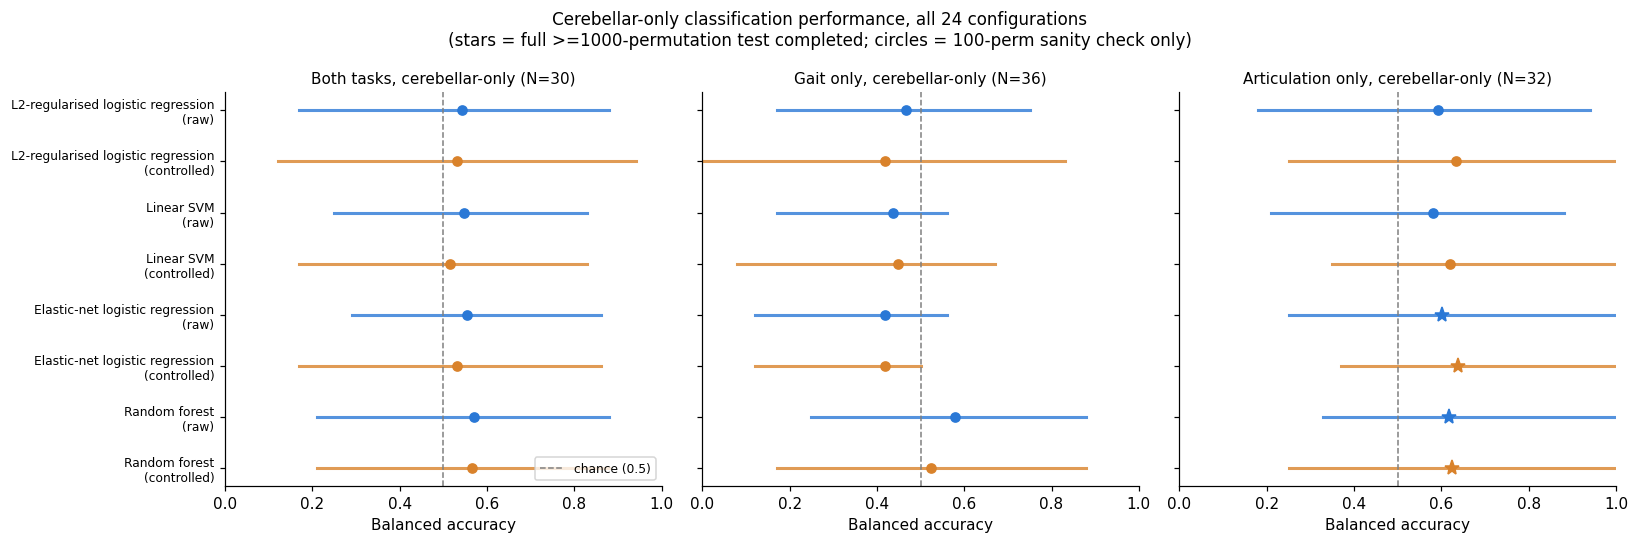

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
cerebellar_titles = {
    "primary_both_tasks_cerebellar_only": "Both tasks, cerebellar-only (N=30)",
    "secondary_gait_only_cerebellar_only": "Gait only, cerebellar-only (N=36)",
    "secondary_articulation_only_cerebellar_only": "Articulation only, cerebellar-only (N=32)",
}

for ax, (dataset, title) in zip(axes, cerebellar_titles.items()):
    sub = all_cerebellar[all_cerebellar["Dataset"] == dataset].reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        lo, hi = [float(x) for x in row["95% CI"].strip("[]").split(",")]
        color = "#2a78d6" if row["Variant"] == "raw" else "#d9822b"
        ax.plot([lo, hi], [ypos[i], ypos[i]], color=color, lw=2, alpha=0.8)
        marker = "*" if row["Full perm. p (n>=1000)"] != "not run" else "o"
        ax.plot(row["Bal. acc."], ypos[i], marker, color=color, markersize=10 if marker == "*" else 6)
    ax.axvline(CHANCE, color="grey", linestyle="--", lw=1, label="chance (0.5)")
    ax.set_yticks(ypos)
    ax.set_yticklabels([f"{r['Model'].split(' (')[0]}\n({r['Variant']})" for _, r in sub.iterrows()], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Balanced accuracy")
    ax.set_xlim(0, 1)

axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Cerebellar-only classification performance, all 24 configurations\n"
             "(stars = full >=1000-permutation test completed; circles = 100-perm sanity check only)", fontsize=11)
plt.tight_layout()
plt.show()

**Arm 1 (both-tasks, cerebellar-only) is a clean null**: sanity-check p ranges 0.21–0.36 across all 8 configurations, well above any reasonable bar even before correction, and point estimates (bal. acc. 0.51–0.57) are comparable to or slightly below the matched whole-brain numbers for the same subjects in Section 6. Nothing here was close enough to justify the full permutation test.

**Arm 2 (per-task, cerebellar-only) splits sharply by task.** Gait-only cerebellar is flat-to-below chance for every linear model (bal. acc. 0.42–0.47, sanity p 0.61–0.84); random forest is marginally above chance (0.53–0.58) but far from significant (p=0.22–0.43). **Articulation-only cerebellar is the closest any configuration in the entire ML strand has come to the significance bar**: all 8 configurations sit above chance (bal. acc. 0.58–0.64), with sanity p as low as 0.079 (elastic-net, controlled). This is still short of uncorrected p<.05, and every 95% CI still includes 0.5 — the pre-specified criterion is not met by the sanity check alone — but it was close enough, and consistent enough across all 4 model families, to be flagged as a genuine decision point rather than dismissed outright (CLAUDE_ML.md §9: closer-than-anywhere-else patterns are exactly the case that needs an explicit go-ahead before spending compute on the full test, not something to chase automatically).

**Arm 3 resolves that flagged pattern with the real test.** Elastic-net and random forest — the two model families closest to the sanity threshold — were re-run through the full ≥1000-permutation significance test on the articulation-only cerebellar dataset:

In [21]:
arm3_resolution = all_cerebellar[
    (all_cerebellar["Dataset"] == "secondary_articulation_only_cerebellar_only")
    & (all_cerebellar["Full perm. p (n>=1000)"] != "not run")
][["Model", "Variant", "Bal. acc.", "95% CI", "Full perm. p (n>=1000)", "Meets positive-result criterion"]].reset_index(drop=True)

BONFERRONI_STRAND_WIDE = 0.05 / 68  # 68 tests run across the whole ML strand as of this arm (ml_plan.md)
arm3_resolution["p < .05 (uncorrected)"] = arm3_resolution["Full perm. p (n>=1000)"] < 0.05
arm3_resolution["p < Bonferroni (68 tests)"] = arm3_resolution["Full perm. p (n>=1000)"] < BONFERRONI_STRAND_WIDE
print(f"Strand-wide Bonferroni threshold (68 tests total, this arm included): p < {BONFERRONI_STRAND_WIDE:.5f}")
arm3_resolution

Strand-wide Bonferroni threshold (68 tests total, this arm included): p < 0.00074


,Model,Variant,Bal. acc.,95% CI,Full perm. p (n>=1000),Meets positive-result criterion,p < .05 (uncorrected),p < Bonferroni (68 tests)
0,Elastic-net logistic regression (secondary),raw,0.602,"[0.25, 1.00]",0.1249,False,False,False
1,Elastic-net logistic regression (secondary),controlled,0.638,"[0.37, 1.00]",0.0669,False,False,False
2,Random forest (exploratory only -- CLAUDE_ML.md §5),raw,0.617,"[0.33, 1.00]",0.1399,False,False,False
3,Random forest (exploratory only -- CLAUDE_ML.md §5),controlled,0.624,"[0.25, 1.00]",0.1149,False,False,False


**None of the 4 configurations crosses even the uncorrected p<.05 bar**, let alone the strand-wide Bonferroni threshold — the closest, elastic-net confound-controlled, lands at p=0.067. Every 95% CI still includes chance. **The pre-specified positive-result criterion is not met by any configuration.** The pattern flagged in arm 2 as "the closest anything in this project has come to significance" does not survive the real test at the confirmatory permutation count.

**What this section adds, and what it does not change.** The cerebellar-restricted feature set does not rescue the classification question at this sample size in either the both-tasks or per-task framing — three independent attempts at a cerebellum-specific hypothesis (arms 1–3) are all null. This is a different, complementary kind of null from Section 6's whole-brain result: it specifically tests whether a *smaller, theoretically-motivated* feature subset does better than the full ROI set, and finds that it does not, task-by-task, exactly as the whole-brain result does not. This arm was run and reported entirely under the same post-hoc-disclosure discipline as Section 8, sits alongside (not instead of) the Section 6 primary conclusion, and does not change `reports/ml_report.md`'s reported result. Full narrative, motivation, and the same numbers shown here are logged in `ml_plan.md`'s third, fourth, and fifth change-log entries; per-arm detail is in `reports/ml_cerebellar_only_report.md` and `reports/ml_cerebellar_only_by_task_report.md`.

A separate, non-confirmatory hyperparameter-tuning teaching exercise was also run on the articulation-only cerebellar dataset (same two model families as arm 3), explicitly framed as diploma-report methodology demonstration rather than a search for significance — logged only in `reports/ml_teaching_notes.md` per `CLAUDE_REPORT_ML.md` §5, not here, since it is not part of the confirmatory pipeline (same convention as the `ml_17` teaching exercise referenced nowhere in Sections 1–10 above for the same reason).

## Reproducibility

This notebook is the presentation layer over the real analysis scripts, not a reimplementation of them — every function shown or imported above (`build_pipeline`, `ConfoundResidualizer`, `MODEL_SPECS`) is imported directly from the scripts in `code/`, so this notebook cannot silently drift out of sync with what was actually run. The full pipeline, in order:

| Script | Purpose |
|---|---|
| `ml_01_check_alignment.py` | Verify imaging/label alignment, compute usable N |
| `ml_02_confound_checks.py` | Confound characterisation (Section 3) |
| `ml_03_extract_features.py` | ROI-average first-level contrasts into features |
| `ml_04_build_datasets.py` | Assemble the primary/secondary feature matrices |
| `ml_05_nested_cv.py` | Primary classification, nested CV (Section 6) |
| `ml_06_mabc2_regression.py` | MABC-2 continuous regression (Section 7a) |
| `ml_07_cross_task_generalization.py` | Cross-task generalisation (Section 7b) |
| `ml_08_generate_report.py` | Compiles `reports/ml_report.md` from the JSON results |
| `ml_09_exploratory_hyperparams.py` / `ml_10_exploratory_permutation_test.py` | Post-hoc wide-grid search (Section 8) |
| `ml_permutation_test.py` | ≥1000-permutation significance test, primary + secondary + extensions + cerebellar arm 3 |
| `ml_14_error_analysis.py` | Per-subject out-of-fold prediction logging (Section 9) |
| `ml_18_cerebellar_only_classification.py` | Cerebellar-only, both-tasks-required (Section 11, arm 1) |
| `ml_19_cerebellar_only_by_task.py` | Cerebellar-only, per-task (Section 11, arm 2) |
| `ml_20_teaching_tuning_articulation_cerebellar.py` | Teaching-track tuning exercise (articulation cerebellar) — not shown here, see `reports/ml_teaching_notes.md` |

Environment used to produce the results shown in this notebook:

In [22]:
import sklearn
import scipy
import platform

print(f"Python      {platform.python_version()}")
print(f"scikit-learn {sklearn.__version__}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"scipy       {scipy.__version__}")

Python      3.12.2
scikit-learn 1.7.2
numpy       1.26.4
pandas      2.3.3
scipy       1.11.4
